## New Strategy: bs_reversal

In [1]:
%load_ext autoreload
%autoreload 2
from qrt.data import *
from qrt.utils import *
from qrt.constants import *
from qrt.qrt_utils import *
from qrt.strategies import *

### Load Raw Data

In [3]:
historical_bb = pd.read_parquet(PRICE_DIR / BB_HISTORICAL)
active_lseg = pd.read_parquet(PRICE_DIR / LSEG_ACTIVE)

### Active Constituents Data

In [4]:
active_prices_rua, active_vol_rua = get_timeseries(active_lseg, stock_index=RUA), get_timeseries(active_lseg, value='Volume', stock_index=RUA)
active_eligible_rua = eligible_to_trade(active_prices_rua, active_vol_rua, stock_index=RUA)
active_returns_rua = active_prices_rua.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

active_prices_stoxx, active_vol_stoxx = get_timeseries(active_lseg, stock_index=STOXX), get_timeseries(active_lseg, value='Volume', stock_index=STOXX)
active_eligible_stoxx = eligible_to_trade(active_prices_stoxx, active_vol_stoxx, stock_index=STOXX)
active_returns_stoxx = active_prices_stoxx.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

### Historical Constituents Data

In [5]:
hist_prices_rua, hist_vol_rua = get_timeseries(historical_bb, stock_index=RUA, data_type='historical'), get_timeseries(historical_bb, value='Volume', stock_index=RUA, data_type='historical')
hist_eligible_rua = eligible_to_trade(hist_prices_rua, hist_vol_rua, stock_index=RUA)
hist_returns_rua = hist_prices_rua.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

hist_prices_stoxx, hist_vol_stoxx = get_timeseries(historical_bb, stock_index=STOXX, data_type='historical'), get_timeseries(historical_bb, value='Volume', stock_index=STOXX, data_type='historical')
hist_eligible_stoxx = eligible_to_trade(hist_prices_stoxx, hist_vol_stoxx, stock_index=STOXX)
hist_returns_stoxx = hist_prices_stoxx.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

### 1. Run strategy with active stocks

In [10]:
weights_rua, stats_rua = titman_min_var_momentum(
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua, 
    stock_index=RUA,
    portfolio_start=str(active_returns_rua.index[-1].date())
)
weights_stoxx, stats_stoxx = titman_min_var_momentum(
    return_data=active_returns_stoxx, 
    volume_eligible=active_eligible_stoxx, 
    stock_index=STOXX,
    portfolio_start=str(active_returns_stoxx.index[-1].date())
)

pd.concat([pd.Series(stats_rua, name=RUA.name), pd.Series(stats_stoxx, name=STOXX.name)], axis=1)

,RUA,STOXX
Portfolio Start,2026-04-09,2026-04-10
In-Sample Return,183.29%,116.01%
In-Sample Vol,9.98%,9.97%
In-Sample Sharpe,18.37,11.64
Beta,0.001,-0.008
Positions,86,46
Longs,44,24
Shorts,42,22
Gross Leverage,1.96x,1.99x


### 2. Backtest with historical data

/Users/dcunning/Code/Python/imperial/QRT/qrt/utils.py:91:FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


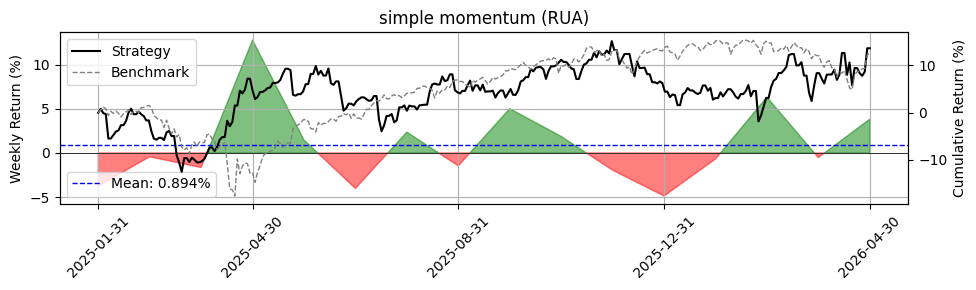

/Users/dcunning/Code/Python/imperial/QRT/qrt/utils.py:91:FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


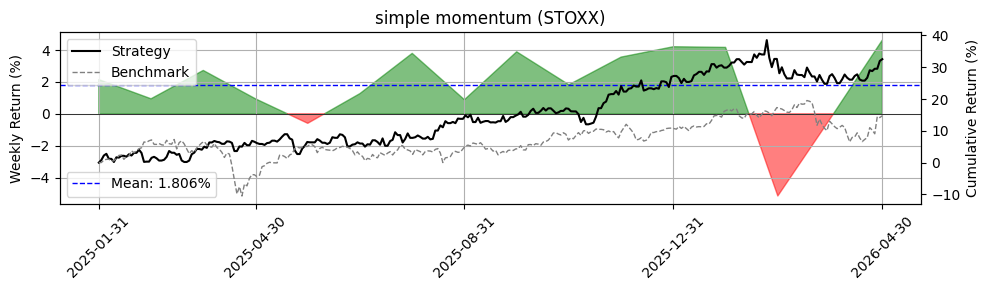

In [31]:
# SIM MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date='2025-01-20',
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=252,
    skip_last=21
)
# SIM MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=active_returns_stoxx, 
    volume_eligible=active_eligible_stoxx,
    stock_index=STOXX,
    start_date='2025-01-20',
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=252,
    skip_last=21
)


In [ ]:
daily_ret, summary = backtest(
    strategy_fn=titman_min_var_momentum,
    price_data=hist_prices_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date='2025-11-20',
    end_date='2026-03-20',
    rebalance_freq=5,
    # strategy_fn args:
    mom_quantile_top=0.8,
    mom_quantile_bottom=0.2,
    lookback=252,
    vol_quantile=0.95,
    target_vol=0.15
)
summary

### 3. Combine RUA & Stoxx porfolios, and scale risk to 500k USD

In [ ]:
scaled_rua, scaled_stoxx = scale_portfolio_risk(
    weights_rua=weights_rua,
    weights_stoxx=weights_stoxx,
    target_risk_usd=500_000,
    display_stats=True
)

### 4. Plot Recent Performance & Submit Positions to QRT

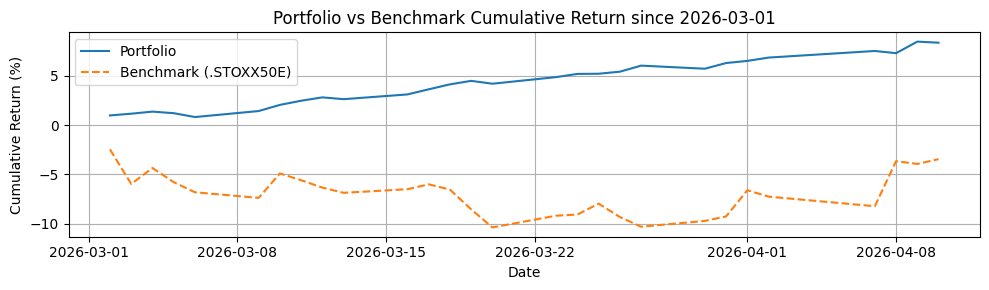

In [ ]:
for pos, stk in [(scaled_rua, RUA), (scaled_stoxx, STOXX)]:
    send_new_portfolio(positions=pos, stock_index=stk, validate_only=True)

positions = most_recent_positions(stock_index=STOXX)
plot_portfolio_returns(positions, stock_index=STOXX, start_date='2026-03-01', figsize=(10,3))

## Competition Instrunctions

### Hedging
To hedge excessive residual beta in your equity portfolio:
1.	Compute the beta of each stock using a 250-day covariance with its benchmark:
$$\text{Beta} = 0.2 + 0.8 \times \frac{\text{Cov}_{250d}(\text{stock}, \text{benchmark})}{\text{Var}_{250d}(\text{benchmark})}$$
2. Hedge the beta exposure by taking a position in the benchmark equal to:
$$\text{Hedge Position} = -\text{Beta}$$
3. Benchmarks:
  - AMER: S&P 500 (SPX)
  - EMEA: Eurostoxx50

This means that if a stock has a beta of 1.2, you would short 1.2 units of the benchmark to neutralize the market exposure.

### Trading Limits
There are some trading limits for single stocks: 
- Max position = 2.5% of the 60 trading days ADV 
- Max traded per day = 2.5% of the 60 trading days ADV 

For single stocks, there is also a max position in term of USD: 
- Max position = 2 M USD 

If the implied trading by targets exceeds the above limits, the position will be kept constant until all limits are not exceeded anymore. 

### Trading Costs
The execution price will be the mid-price at the end of the next minute after we have received your file (without format error) on the ftp. Additional execution costs of 2bps also apply, along with 0.5% (annually) for financing. 

100% of dividends are paid on short positions. 70% of dividends are received on long positions. 

### Ex-Ante Portfolio Risk

Risk Formula
$$
\text{Risk}_t = \sqrt{ x_t^\top \, \Sigma_t \, x_t }
$$

Where:
- $x_t$ = portfolio weights at time $t$
- $\Sigma_t$ = covariance matrix of asset returns  

Computation Steps
1. Select last 60 daily returns.  
2. Compute daily P&L:

$$
\text{PnL}_t = \text{positions}_{t-1} \cdot \text{return}_t
$$

3. Compute standard deviation of P&L.  
4. Annualise: multiply by $\sqrt{252}$.  

Simulation Parameters
- Asset class: Equities  
- Regions: AMER, EMEA  
- Universe: Russell 3000, Stoxx 600  
- Trading hours: Standard per region  
- Execution cost: 2 bps  
- Financing cost: 0.5% GMV  
- Dividend tax: 30%  
- Spread cost: 0  
- Max traded/day: 2.5% ADV  
- Position limit: 2.5% ADV  
- Auto-hedging: TRUE  
- Risk limit: 500k USD (annualised)